Bank Customer Churn — Prediction & Decision System

Dataset: IBM "Churn Modelling" sample — 10,000 zboun min bank fransa . Target: Exited (1 = churned, 0 = stayed) — Binary Classification.

Pipeline:

1.EDA (Exploratory Data Analysis)
2.Feature Engineering
3.Preprocessing + handling class imbalance
4.Model training & comparison (Logistic Regression, Random Forest, XGBoost) with RandomizedSearchCV
5.Explainability with SHAP
6.Per-customer decision system (Risk Tier + Reasons + Recommended Action)
7.Export final report (Excel + CSV)


In [35]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
import xgboost as xgb

from sklearn import metrics
from sklearn.metrics import accuracy_score, auc, confusion_matrix, roc_auc_score, roc_curve, recall_score

1. Load Data & EDA

In [11]:
df_raw = pd.read_csv("/Users/sajaa7/Downloads/Churn_Modelling.csv.xls")

print(df_raw.shape)
print(df_raw.dtypes)
print(df_raw.isnull().sum())


(10000, 14)
RowNumber            int64
CustomerId           int64
Surname                str
CreditScore          int64
Geography              str
Gender                 str
Age                  int64
Tenure               int64
Balance            float64
NumOfProducts        int64
HasCrCard            int64
IsActiveMember       int64
EstimatedSalary    float64
Exited               int64
dtype: object
RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64


In [13]:
print("Churn rate (Exited):")
print(df_raw['Exited'].value_counts(normalize=True))

df_raw.describe().T

Churn rate (Exited):
Exited
0    0.7963
1    0.2037
Name: proportion, dtype: float64


,count,mean,std,min,25%,50%,75%,max
RowNumber,10000.0,5.000500e+03,2886.895680,1.00,2500.75,5.000500e+03,7.500250e+03,10000.00
CustomerId,10000.0,1.569094e+07,71936.186123,15565701.00,15628528.25,1.569074e+07,1.575323e+07,15815690.00
CreditScore,10000.0,6.505288e+02,96.653299,350.00,584.00,6.520000e+02,7.180000e+02,850.00
Age,10000.0,3.892180e+01,10.487806,18.00,32.00,3.700000e+01,4.400000e+01,92.00
Tenure,10000.0,5.012800e+00,2.892174,0.00,3.00,5.000000e+00,7.000000e+00,10.00
Balance,10000.0,7.648589e+04,62397.405202,0.00,0.00,9.719854e+04,1.276442e+05,250898.09
NumOfProducts,10000.0,1.530200e+00,0.581654,1.00,1.00,1.000000e+00,2.000000e+00,4.00
HasCrCard,10000.0,7.055000e-01,0.455840,0.00,0.00,1.000000e+00,1.000000e+00,1.00
IsActiveMember,10000.0,5.151000e-01,0.499797,0.00,0.00,1.000000e+00,1.000000e+00,1.00
EstimatedSalary,10000.0,1.000902e+05,57510.492818,11.58,51002.11,1.001939e+05,1.493882e+05,199992.48


In [14]:
print("Churn rate by Geography:")
print(df_raw.groupby('Geography')['Exited'].mean().round(3))

print("\nChurn rate by Gender:")
print(df_raw.groupby('Gender')['Exited'].mean().round(3))

print("\nChurn rate by NumOfProducts:")
print(df_raw.groupby('NumOfProducts')['Exited'].mean().round(3))

print("\nChurn rate by IsActiveMember:")
print(df_raw.groupby('IsActiveMember')['Exited'].mean().round(3))


Churn rate by Geography:
Geography
France     0.162
Germany    0.324
Spain      0.167
Name: Exited, dtype: float64

Churn rate by Gender:
Gender
Female    0.251
Male      0.165
Name: Exited, dtype: float64

Churn rate by NumOfProducts:
NumOfProducts
1    0.277
2    0.076
3    0.827
4    1.000
Name: Exited, dtype: float64

Churn rate by IsActiveMember:
IsActiveMember
0    0.269
1    0.143
Name: Exited, dtype: float64


Exploratory Data Analysis

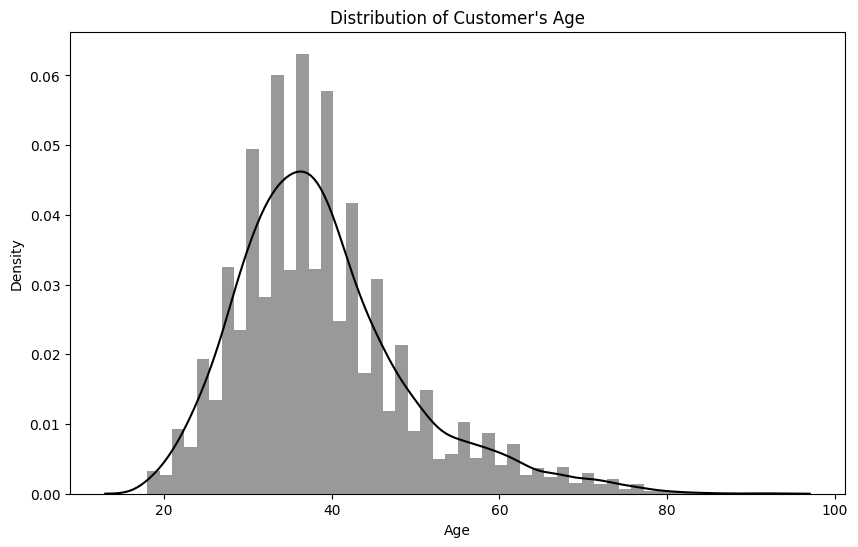

In [16]:
plt.figure(figsize=(10,6))
sns.distplot(df['Age'], color='black')
plt.title("Distribution of Customer's Age");

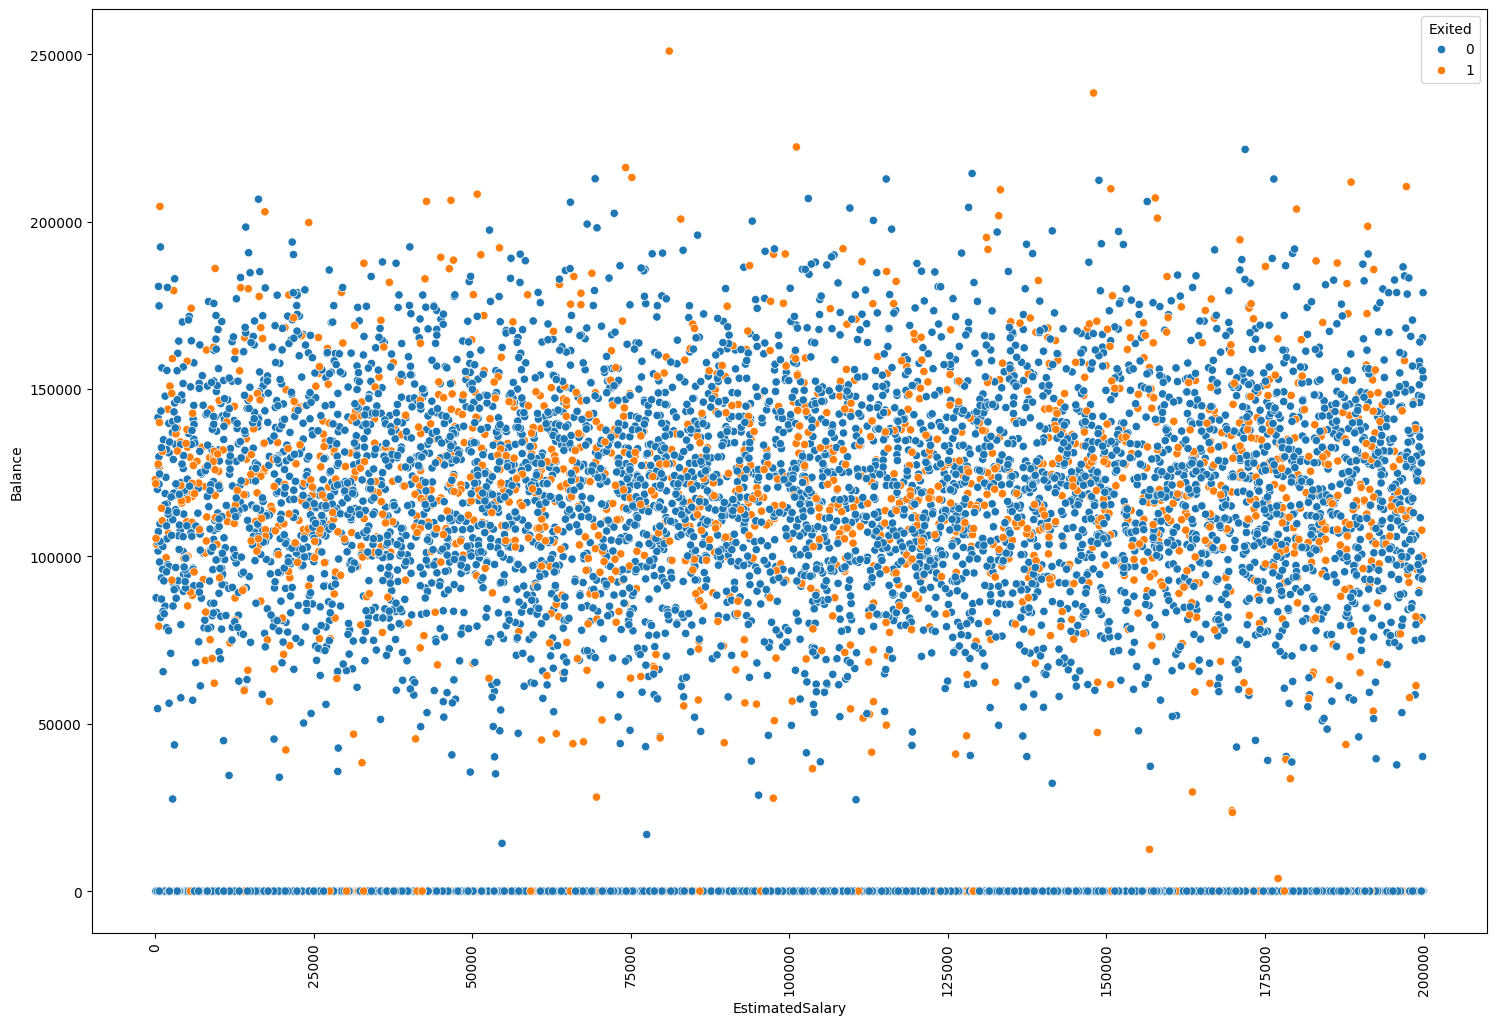

In [17]:
plt.figure(figsize=(18,12))
plt.xticks(rotation=90)
sns.scatterplot(data=df, x='EstimatedSalary', y='Balance', hue='Exited');

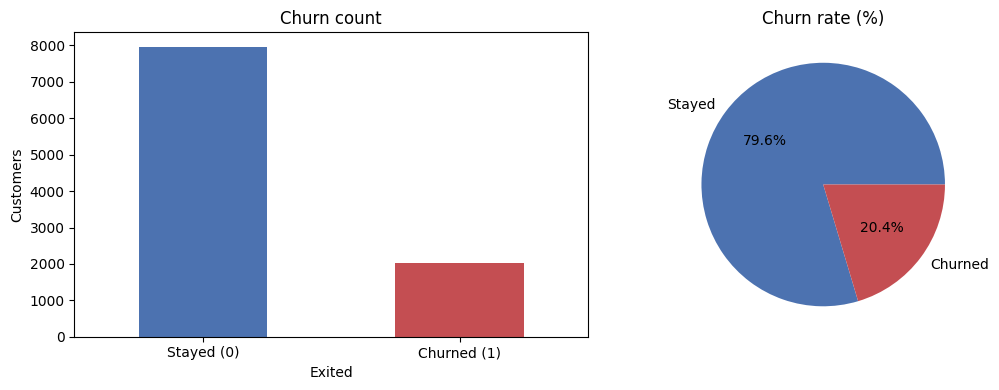

In [19]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4))

df_raw['Exited'].value_counts().plot(kind='bar', ax=ax[0], color=['#4C72B0', '#C44E52'])
ax[0].set_xticklabels(['Stayed (0)', 'Churned (1)'], rotation=0)
ax[0].set_title('Churn count')
ax[0].set_ylabel('Customers')

df_raw['Exited'].value_counts(normalize=True).plot(kind='pie', ax=ax[1], autopct='%1.1f%%',
                                                     labels=['Stayed', 'Churned'],
                                                     colors=['#4C72B0', '#C44E52'])
ax[1].set_ylabel('')
ax[1].set_title('Churn rate (%)')

plt.tight_layout()
plt.show()


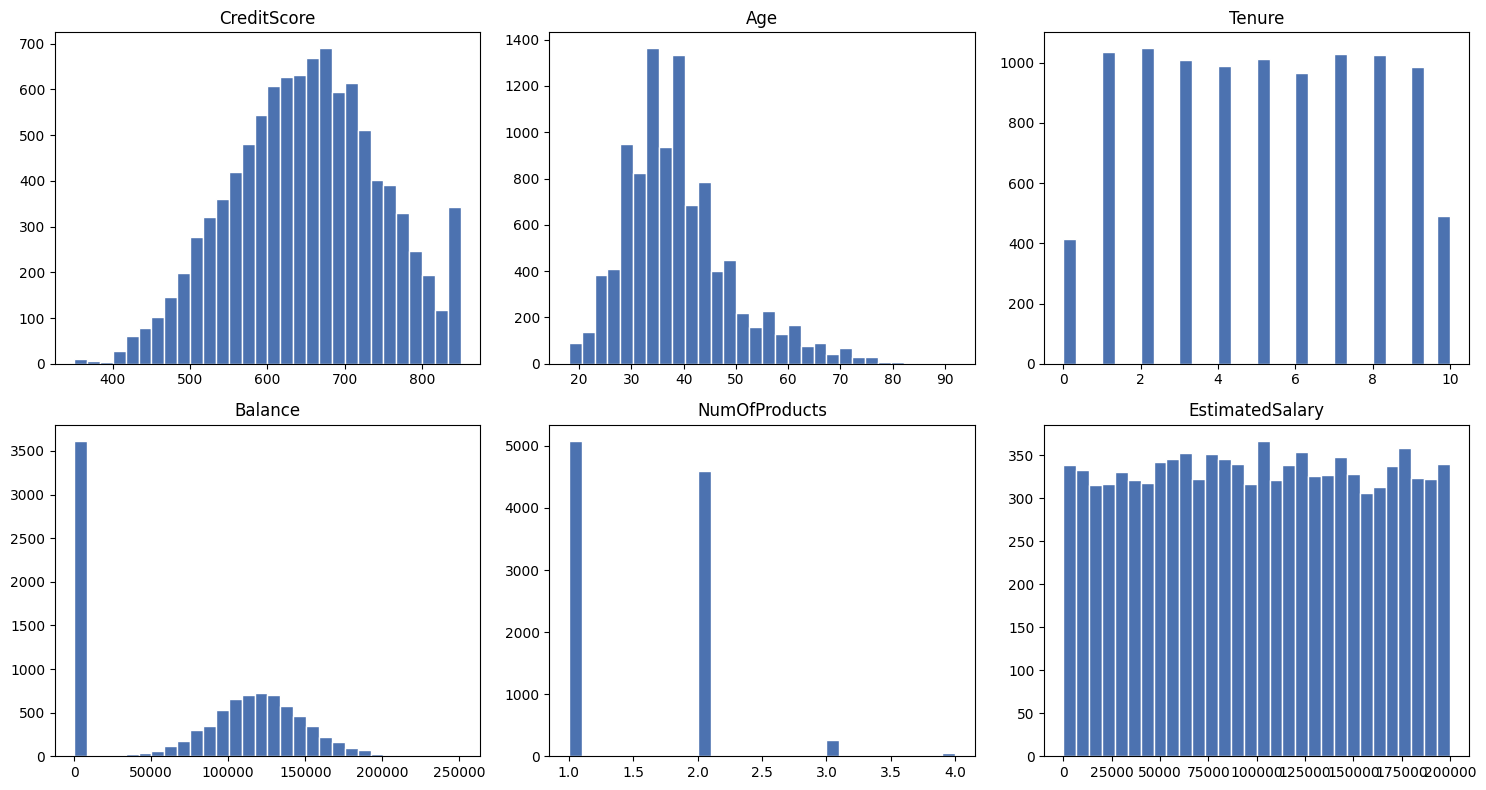

In [21]:
num_features = ['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'EstimatedSalary']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, col in zip(axes.flatten(), num_features):
    ax.hist(df_raw[col], bins=30, color='#4C72B0', edgecolor='white')
    ax.set_title(col)
plt.tight_layout()
plt.show()


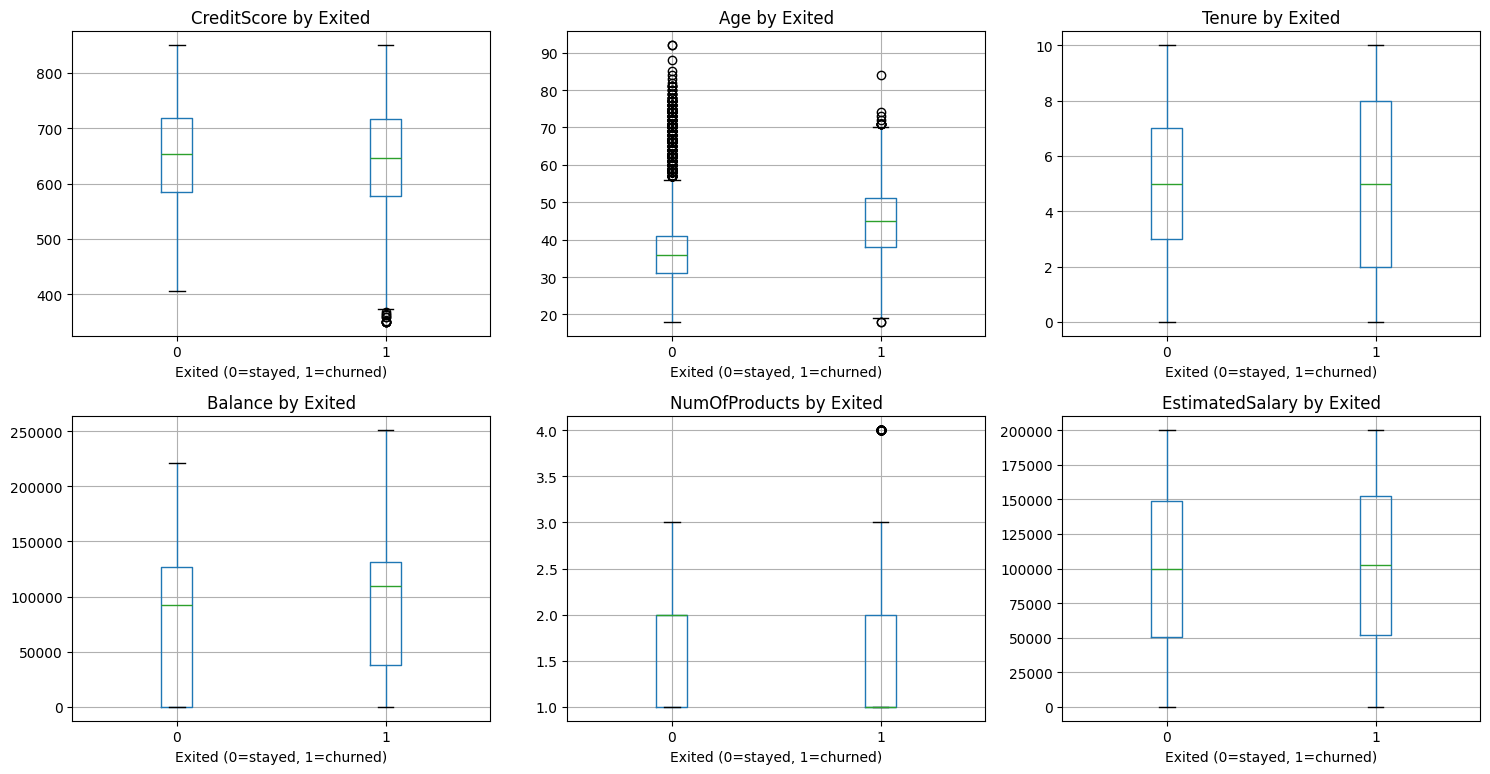

In [22]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, col in zip(axes.flatten(), num_features):
    df_raw.boxplot(column=col, by='Exited', ax=ax)
    ax.set_title(f'{col} by Exited')
    ax.set_xlabel('Exited (0=stayed, 1=churned)')
plt.suptitle('')
plt.tight_layout()
plt.show()


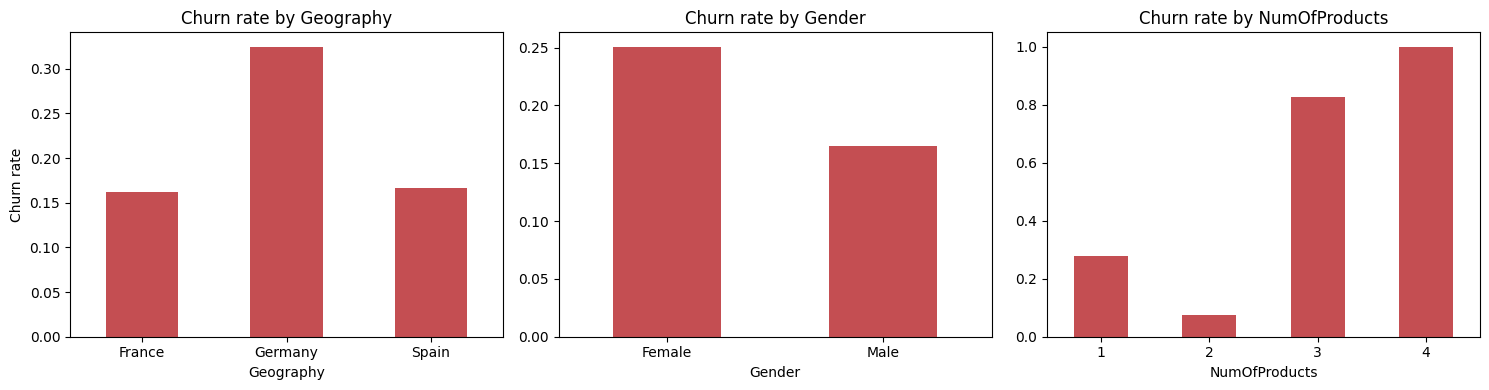

In [23]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

df_raw.groupby('Geography')['Exited'].mean().plot(kind='bar', ax=axes[0], color='#C44E52')
axes[0].set_title('Churn rate by Geography')
axes[0].set_ylabel('Churn rate')

df_raw.groupby('Gender')['Exited'].mean().plot(kind='bar', ax=axes[1], color='#C44E52')
axes[1].set_title('Churn rate by Gender')

df_raw.groupby('NumOfProducts')['Exited'].mean().plot(kind='bar', ax=axes[2], color='#C44E52')
axes[2].set_title('Churn rate by NumOfProducts')

for ax in axes:
    ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
plt.tight_layout()
plt.show()


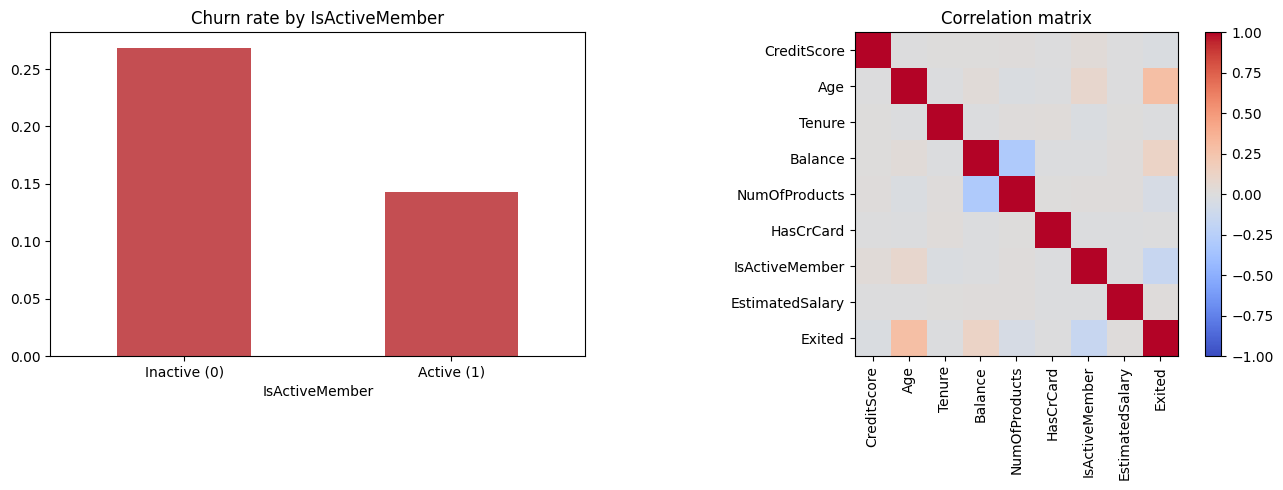

Correlation with Exited (sorted):
Exited             1.000000
Age                0.285323
Balance            0.118533
EstimatedSalary    0.012097
HasCrCard         -0.007138
Tenure            -0.014001
CreditScore       -0.027094
NumOfProducts     -0.047820
IsActiveMember    -0.156128
Name: Exited, dtype: float64


In [25]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

df_raw.groupby('IsActiveMember')['Exited'].mean().plot(kind='bar', ax=axes[0], color='#C44E52')
axes[0].set_title('Churn rate by IsActiveMember')
axes[0].set_xticklabels(['Inactive (0)', 'Active (1)'], rotation=0)

corr_cols = ['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts',
             'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Exited']
corr = df_raw[corr_cols].corr()
im = axes[1].imshow(corr, cmap='coolwarm', vmin=-1, vmax=1)
axes[1].set_xticks(range(len(corr_cols)))
axes[1].set_xticklabels(corr_cols, rotation=90)
axes[1].set_yticks(range(len(corr_cols)))
axes[1].set_yticklabels(corr_cols)
axes[1].set_title('Correlation matrix')
plt.colorbar(im, ax=axes[1], fraction=0.046)

plt.tight_layout()
plt.show()

print("Correlation with Exited (sorted):")
print(corr['Exited'].sort_values(ascending=False))


2. Feature Engineering

In [27]:
df = df_raw.drop(columns=['RowNumber', 'Surname'])  


df['ZeroBalance'] = (df['Balance'] == 0).astype(int)
df['BalanceSalaryRatio'] = df['Balance'] / (df['EstimatedSalary'] + 1)
df['HighProductCount'] = (df['NumOfProducts'] >= 3).astype(int)
df['IsGermany'] = (df['Geography'] == 'Germany').astype(int)
df['TenureByAge'] = df['Tenure'] / df['Age']
df['CreditScoreBin'] = pd.cut(df['CreditScore'], bins=[0, 580, 670, 740, 800, 850],
                               labels=['Poor', 'Fair', 'Good', 'VeryGood', 'Excellent'])
df['AgeGroup'] = pd.cut(df['Age'], bins=[17, 30, 40, 50, 60, 100],
                         labels=['18-30', '31-40', '41-50', '51-60', '60+'])
df['InactiveSenior'] = ((df['IsActiveMember'] == 0) & (df['Age'] >= 50)).astype(int)
df['ProductsPerTenure'] = df['NumOfProducts'] / (df['Tenure'] + 1)

print(df.shape)
print(df.columns.tolist())
df[['ZeroBalance', 'BalanceSalaryRatio', 'HighProductCount', 'IsGermany',
    'TenureByAge', 'InactiveSenior']].describe().T


(10000, 21)
['CustomerId', 'CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Exited', 'ZeroBalance', 'BalanceSalaryRatio', 'HighProductCount', 'IsGermany', 'TenureByAge', 'CreditScoreBin', 'AgeGroup', 'InactiveSenior', 'ProductsPerTenure']


,count,mean,std,min,25%,50%,75%,max
ZeroBalance,10000.0,0.361700,0.480517,0.0,0.000000,0.000000,1.000000,1.000000
BalanceSalaryRatio,10000.0,3.790150,100.055758,0.0,0.000000,0.746998,1.514002,9770.883148
HighProductCount,10000.0,0.032600,0.177596,0.0,0.000000,0.000000,0.000000,1.000000
IsGermany,10000.0,0.250900,0.433553,0.0,0.000000,0.000000,1.000000,1.000000
TenureByAge,10000.0,0.137936,0.089506,0.0,0.064516,0.129032,0.200000,0.555556
InactiveSenior,10000.0,0.048400,0.214621,0.0,0.000000,0.000000,0.000000,1.000000


In [28]:
df.to_csv('features.csv', index=False)
print("Saved features.csv")

Saved features.csv


3. Train/Test Split & Preprocessing Pipeline¶

In [29]:
from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, average_precision_score, classification_report, confusion_matrix
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
import xgboost as xgb
import joblib
import os

os.makedirs('outputs', exist_ok=True)

target = 'Exited'
id_col = 'CustomerId'
X = df.drop(columns=[id_col, target])
y = df[target]

cat_cols = ['Geography', 'Gender', 'CreditScoreBin', 'AgeGroup']
num_cols = [c for c in X.columns if c not in cat_cols]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print("Train shape:", X_train.shape, "Test shape:", X_test.shape)
print("Train churn rate:", round(y_train.mean(), 4), "Test churn rate:", round(y_test.mean(), 4))

preprocess = ColumnTransformer([
    ('num', StandardScaler(), num_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore', drop='if_binary'), cat_cols)
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)


Train shape: (8000, 19) Test shape: (2000, 19)
Train churn rate: 0.2037 Test churn rate: 0.2035


4. Model Training & Comparison

In [30]:
# ---------------- Logistic Regression (baseline) ----------------
logreg_pipe = Pipeline([
    ('prep', preprocess),
    ('clf', LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42))
])
logreg_pipe.fit(X_train, y_train)
logreg_proba = logreg_pipe.predict_proba(X_test)[:, 1]

print("=== Logistic Regression (baseline, class_weight=balanced) ===")
print("ROC-AUC:", round(roc_auc_score(y_test, logreg_proba), 4))
print("PR-AUC :", round(average_precision_score(y_test, logreg_proba), 4))


=== Logistic Regression (baseline, class_weight=balanced) ===
ROC-AUC: 0.8502
PR-AUC : 0.6887


In [31]:
# ---------------- Random Forest (tuned) ----------------
rf_pipe = Pipeline([
    ('prep', preprocess),
    ('clf', RandomForestClassifier(class_weight='balanced', random_state=42))
])
rf_params = {
    'clf__n_estimators': [200, 400, 600],
    'clf__max_depth': [4, 6, 8, 12, None],
    'clf__min_samples_split': [2, 5, 10],
    'clf__min_samples_leaf': [1, 2, 4],
    'clf__max_features': ['sqrt', 'log2']
}
rf_search = RandomizedSearchCV(rf_pipe, rf_params, n_iter=25, scoring='roc_auc',
                                cv=cv, random_state=42, n_jobs=-1)
rf_search.fit(X_train, y_train)
rf_best = rf_search.best_estimator_
rf_proba = rf_best.predict_proba(X_test)[:, 1]

print("=== Random Forest (tuned, class_weight=balanced) ===")
print("Best params:", rf_search.best_params_)
print("ROC-AUC:", round(roc_auc_score(y_test, rf_proba), 4))
print("PR-AUC :", round(average_precision_score(y_test, rf_proba), 4))


=== Random Forest (tuned, class_weight=balanced) ===
Best params: {'clf__n_estimators': 600, 'clf__min_samples_split': 5, 'clf__min_samples_leaf': 4, 'clf__max_features': 'sqrt', 'clf__max_depth': 12}
ROC-AUC: 0.8612
PR-AUC : 0.7063


In [32]:
# ---------------- XGBoost (tuned, scale_pos_weight) ----------------
neg, pos = np.bincount(y_train)
spw = neg / pos

xgb_pipe = Pipeline([
    ('prep', preprocess),
    ('clf', xgb.XGBClassifier(objective='binary:logistic', eval_metric='auc',
                               scale_pos_weight=spw, random_state=42, n_jobs=-1,
                               tree_method='hist'))
])
xgb_params = {
    'clf__n_estimators': [200, 300, 500],
    'clf__max_depth': [3, 4, 5, 6],
    'clf__learning_rate': [0.01, 0.03, 0.05, 0.1],
    'clf__subsample': [0.7, 0.8, 1.0],
    'clf__colsample_bytree': [0.6, 0.8, 1.0],
    'clf__min_child_weight': [1, 3, 5]
}
xgb_search = RandomizedSearchCV(xgb_pipe, xgb_params, n_iter=30, scoring='roc_auc',
                                 cv=cv, random_state=42, n_jobs=-1)
xgb_search.fit(X_train, y_train)
xgb_best = xgb_search.best_estimator_
xgb_proba = xgb_best.predict_proba(X_test)[:, 1]

print("=== XGBoost (tuned, scale_pos_weight) ===")
print("Best params:", xgb_search.best_params_)
print("ROC-AUC:", round(roc_auc_score(y_test, xgb_proba), 4))
print("PR-AUC :", round(average_precision_score(y_test, xgb_proba), 4))


=== XGBoost (tuned, scale_pos_weight) ===
Best params: {'clf__subsample': 1.0, 'clf__n_estimators': 200, 'clf__min_child_weight': 1, 'clf__max_depth': 3, 'clf__learning_rate': 0.05, 'clf__colsample_bytree': 0.6}
ROC-AUC: 0.8699
PR-AUC : 0.7135


In [33]:
# ---------------- XGBoost + SMOTE (alternative imbalance strategy) ----------------
xgb_smote_pipe = ImbPipeline([
    ('prep', preprocess),
    ('smote', SMOTE(random_state=42)),
    ('clf', xgb.XGBClassifier(objective='binary:logistic', eval_metric='auc',
                               random_state=42, n_jobs=-1,
                               n_estimators=300, max_depth=4, learning_rate=0.05))
])
xgb_smote_pipe.fit(X_train, y_train)
smote_proba = xgb_smote_pipe.predict_proba(X_test)[:, 1]

print("=== XGBoost + SMOTE ===")
print("ROC-AUC:", round(roc_auc_score(y_test, smote_proba), 4))
print("PR-AUC :", round(average_precision_score(y_test, smote_proba), 4))


=== XGBoost + SMOTE ===
ROC-AUC: 0.8648
PR-AUC : 0.7153


In [34]:
# ---------------- Model comparison summary ----------------
comparison = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest (tuned)', 'XGBoost (tuned)', 'XGBoost + SMOTE'],
    'ROC-AUC': [
        roc_auc_score(y_test, logreg_proba),
        roc_auc_score(y_test, rf_proba),
        roc_auc_score(y_test, xgb_proba),
        roc_auc_score(y_test, smote_proba),
    ],
    'PR-AUC': [
        average_precision_score(y_test, logreg_proba),
        average_precision_score(y_test, rf_proba),
        average_precision_score(y_test, xgb_proba),
        average_precision_score(y_test, smote_proba),
    ]
}).sort_values('ROC-AUC', ascending=False).reset_index(drop=True)

print(comparison.round(4))


best_model = xgb_best
joblib.dump(best_model, 'outputs/churn_model.joblib')
joblib.dump({'X_train': X_train, 'X_test': X_test, 'y_train': y_train, 'y_test': y_test,
             'cat_cols': cat_cols, 'num_cols': num_cols},
            'outputs/data_splits.joblib')
print("\nSaved best model -> outputs/churn_model.joblib")


                   Model  ROC-AUC  PR-AUC
0        XGBoost (tuned)   0.8699  0.7135
1        XGBoost + SMOTE   0.8648  0.7153
2  Random Forest (tuned)   0.8612  0.7063
3    Logistic Regression   0.8502  0.6887

Saved best model -> outputs/churn_model.joblib


5. Explainability (SHAP)

In [37]:
import shap

prep = best_model.named_steps['prep']
clf = best_model.named_steps['clf']

X_test_t = prep.transform(X_test)
feature_names = prep.get_feature_names_out()
X_test_df = pd.DataFrame(X_test_t, columns=feature_names, index=X_test.index)

explainer = shap.TreeExplainer(clf)
shap_values = explainer.shap_values(X_test_df)

mean_abs_shap = np.abs(shap_values).mean(axis=0)
importance = pd.Series(mean_abs_shap, index=feature_names).sort_values(ascending=False)

print("=== Top 15 global feature importance (mean |SHAP|) ===")
print(importance.head(15))


=== Top 15 global feature importance (mean |SHAP|) ===
num__NumOfProducts         0.729227
num__Age                   0.637259
num__IsActiveMember        0.285347
cat__Gender_Male           0.233225
num__IsGermany             0.200110
num__InactiveSenior        0.131952
num__BalanceSalaryRatio    0.095644
num__Balance               0.074972
num__HighProductCount      0.064799
cat__Geography_Germany     0.052623
num__EstimatedSalary       0.048980
cat__AgeGroup_41-50        0.047729
num__ZeroBalance           0.042789
num__TenureByAge           0.041654
num__ProductsPerTenure     0.039122
dtype: float32


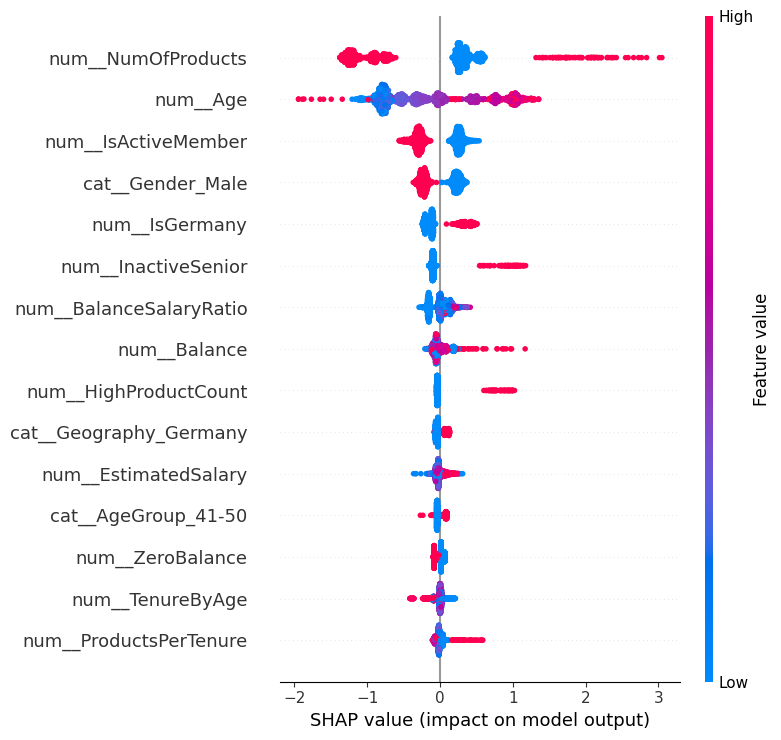

In [43]:
plt.figure()

shap.summary_plot(
    shap_values,
    X_test_df,
    show=False,
    max_display=15,
    color=plt.get_cmap('coolwarm')
)

plt.tight_layout()
plt.show()
plt.close()

6. Per-Customer Decision System

In [44]:
churn_proba = best_model.predict_proba(X_test)[:, 1]

def risk_tier(p):
    if p >= 0.70:
        return 'Critical'
    elif p >= 0.45:
        return 'High'
    elif p >= 0.20:
        return 'Medium'
    else:
        return 'Low'

def top_reasons(row_shap, feat_names, n=3):
    idx_sorted = np.argsort(-row_shap)
    reasons = []
    
    for i in idx_sorted:
        if row_shap[i] > 0:
            reasons.append(feat_names[i])
        if len(reasons) == n:
            break
    
    while len(reasons) < n:
        reasons.append(None)
    
    return reasons

def recommended_action(reasons, num_products):
    top = reasons[0] if reasons[0] else ''
    
    if num_products >= 3:
        return 'Immediate review by Relationship Manager'
    
    if 'IsActiveMember' in top or 'InactiveSenior' in top:
        return 'Re-engagement campaign'
    
    if 'Age' in top:
        return 'Age-specific offer and proactive call'
    
    if 'Germany' in top:
        return 'Review pricing and service in Germany'
    
    return 'Regular follow-up and general retention offer'

report_rows = []

customer_ids = df.loc[X_test.index, 'CustomerId'].values
num_products_arr = X_test['NumOfProducts'].values

for i, cust_id in enumerate(customer_ids):
    reasons = top_reasons(shap_values[i], feature_names, n=3)
    prob = churn_proba[i]
    
    report_rows.append({
        'CustomerId': cust_id,
        'ChurnProbability': round(float(prob), 4),
        'RiskTier': risk_tier(prob),
        'ActualExited': int(y_test.iloc[i]),
        'TopReason1': reasons[0],
        'TopReason2': reasons[1],
        'TopReason3': reasons[2],
        'RecommendedAction': recommended_action(
            reasons,
            num_products_arr[i]
        )
    })

customer_risk_report = pd.DataFrame(report_rows)

customer_risk_report.to_csv(
    'outputs/customer_risk_report.csv',
    index=False
)

print(customer_risk_report.shape)
customer_risk_report.head(10)


(2000, 8)


,CustomerId,ChurnProbability,RiskTier,ActualExited,TopReason1,TopReason2,TopReason3,RecommendedAction
0,15749540,0.0691,Low,0,num__IsActiveMember,cat__AgeGroup_18-30,num__CreditScore,Re-engagement campaign
1,15807340,0.2542,Medium,0,num__IsGermany,num__IsActiveMember,num__BalanceSalaryRatio,Review pricing and service in Germany
2,15801062,0.1507,Low,0,cat__Gender_Male,num__CreditScore,num__HasCrCard,Regular follow-up and general retention offer
3,15572801,0.1874,Low,0,num__IsActiveMember,num__BalanceSalaryRatio,cat__Geography_Spain,Re-engagement campaign
4,15600708,0.3612,Medium,0,num__NumOfProducts,cat__Gender_Male,num__EstimatedSalary,Regular follow-up and general retention offer
5,15703544,0.5438,High,0,num__NumOfProducts,num__IsActiveMember,num__EstimatedSalary,Regular follow-up and general retention offer
6,15704081,0.1399,Low,0,num__IsGermany,num__BalanceSalaryRatio,num__Balance,Review pricing and service in Germany
7,15801788,0.6948,High,0,num__NumOfProducts,num__IsGermany,num__Balance,Regular follow-up and general retention offer
8,15592222,0.7475,Critical,0,num__Age,num__IsActiveMember,num__NumOfProducts,Age-specific offer and proactive call
9,15584338,0.2660,Medium,0,cat__Gender_Male,num__ProductsPerTenure,num__IsActiveMember,Regular follow-up and general retention offer


In [45]:
tier_validation = customer_risk_report.groupby('RiskTier')['ActualExited'].agg(['mean', 'count']).round(3)
tier_validation = tier_validation.reindex(['Critical', 'High', 'Medium', 'Low'])
print("Actual churn rate per RiskTier:")
print(tier_validation)


Actual churn rate per RiskTier:
           mean  count
RiskTier              
Critical  0.707    317
High      0.266    391
Medium    0.096    653
Low       0.025    639


In [46]:
print("Distribution of RecommendedAction across customers:")
print(customer_risk_report['RecommendedAction'].value_counts())


Distribution of RecommendedAction across customers:
RecommendedAction
Regular follow-up and general retention offer    875
Age-specific offer and proactive call            532
Review pricing and service in Germany            297
Re-engagement campaign                           227
Immediate review by Relationship Manager          69
Name: count, dtype: int64


7. Export Final Report (Excel + CSV)

In [48]:
with pd.ExcelWriter('outputs/churn_retention_report.xlsx', engine='xlsxwriter') as writer:
    
    summary = pd.DataFrame({
        'Metric': ['Total customers (test set)', 'Overall churn rate (test)',
                   'Best model', 'Best ROC-AUC', 'Critical tier actual churn %',
                   'Low tier actual churn %'],
        'Value': [len(customer_risk_report), f"{y_test.mean():.1%}",
                  'XGBoost (tuned)', f"{roc_auc_score(y_test, churn_proba):.3f}",
                  f"{tier_validation.loc['Critical', 'mean']:.1%}",
                  f"{tier_validation.loc['Low', 'mean']:.1%}"]
    })
    summary.to_excel(writer, sheet_name='Executive Summary', index=False)

    
    action_plan = customer_risk_report.groupby(['RiskTier', 'RecommendedAction']).size() \
        .reset_index(name='CustomerCount').sort_values(['RiskTier', 'CustomerCount'], ascending=[True, False])
    action_plan.to_excel(writer, sheet_name='Action Plan', index=False)

    
    customer_risk_report.to_excel(writer, sheet_name='Customer Risk Report', index=False)

print("Saved outputs/churn_retention_report.xlsx")


Saved outputs/churn_retention_report.xlsx
